# Retrieving data & cleaning

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas_market_calendars as mcal
from scipy.stats import norm, jarque_bera, kurtosis, skew
import time

### Retrieving AAPL daily close price from 2020-01-01 to 2026-04-27

[*********************100%***********************]  1 of 1 completed

datetime64[ns] <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


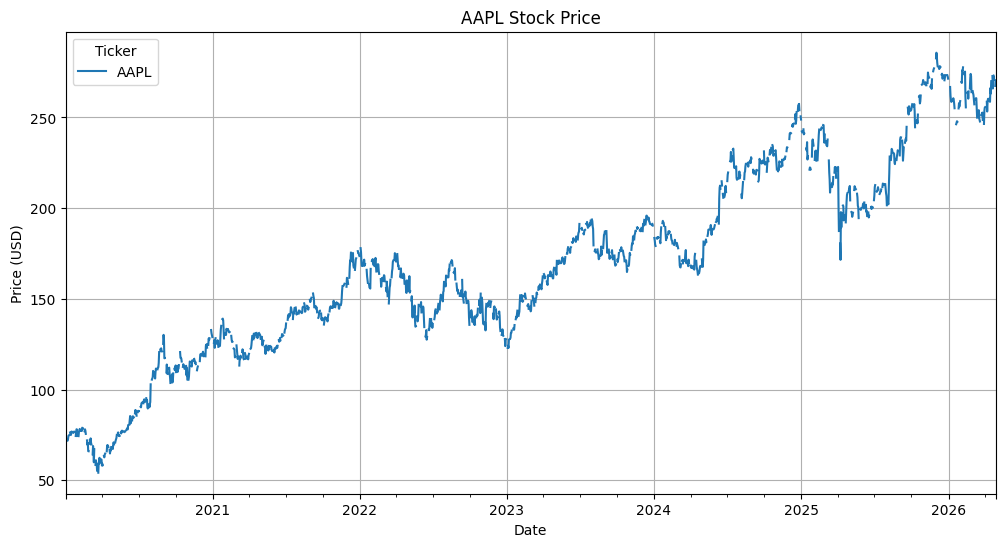

In [4]:
aapl_prices= yf.download("AAPL", start="2020-01-01", end="2026-04-29", auto_adjust=True)['Close'] #automatically adjust for splits and dividends
aapl_prices = aapl_prices.reindex(pd.date_range(aapl_prices.index.min(), aapl_prices.index.max()))
print(aapl_prices.index.dtype, type(aapl_prices.index))

#displaying the dataframe
aapl_prices.plot(title="AAPL Stock Price", figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid()
plt.show()

In [5]:
#displaying and describing the dataframe
display(aapl_prices)


#checking for missing values, and assessing when they occur + if they coincide with  NYSE weekends or holidays
print(aapl_prices.isna().any(axis=1).groupby(aapl_prices.index.day_name()).sum())

nyse = mcal.get_calendar('NYSE')
trading_days = nyse.valid_days(start_date="2020-01-01", end_date="2026-01-01").tz_localize(None)
missing_trading_days = trading_days.difference(aapl_prices.index)
print(f"Number of truly missing trading days: {len(missing_trading_days)}")
print(missing_trading_days)

#dropping missing values
aapl_prices = aapl_prices.dropna()

#checking for outliers by looking at the percentage change and filtering for changes greater than 10%
print(aapl_prices.assign(pct_change=aapl_prices['AAPL'].pct_change()).loc[aapl_prices['AAPL'].pct_change().abs() > 0.10])


Ticker,AAPL
2020-01-02,72.333878
2020-01-03,71.630653
2020-01-04,NaN
2020-01-05,NaN
2020-01-06,72.201401
...,...
2026-04-24,270.810486
2026-04-25,NaN
2026-04-26,NaN
2026-04-27,267.363647


Friday        12
Monday        34
Saturday     330
Sunday       330
Thursday      11
Tuesday        1
Wednesday      3
dtype: int64
Number of truly missing trading days: 0
DatetimeIndex([], dtype='datetime64[ns]', freq=None)
Ticker            AAPL  pct_change
2020-03-13   67.102936    0.119808
2020-03-16   58.470352   -0.128647
2020-03-24   59.597694    0.100325
2020-07-31  102.883904    0.104689
2025-04-09  197.804855    0.153289


#### Missing Values & Temporal Alignment
 Analysis of the AAPL time series reveals that missing data points predominantly coincide with weekends (91.65% of missing values) and scheduled market holidays (8.35% of missing values). We recorded an average of 113.83 missing days per year, which aligns closely with the expected 115 annual non-trading days.

To ensure the integrity of the path-dependent Asian pricer, we have opted to remove these gaps rather than interpolate them. All subsequent mathematical computations, including volatility and the binomial tree's time-step Δt, will be based on a standard 252-day trading year.
 
 #### Extreme Volatility Events
 We identified five specific dates where AAPL’s daily returns exceeded a ±10% threshold. Each event was audited to determine if it represented a "fat-finger" data error or legitimate market risk. Our findings confirm these are valid historical events:

 **2020-03-13** (+11.98% daily gain): This was amid the COVID-19-induced 2020 stock market crash.  U.S. markets rallied sharply, with the Dow Jones, NASDAQ, and S&P 500 each rising over 9% in their largest single-day gains since 2008, following prior circuit breaker halts. Apple followed this trend with a strong rebound from pandemic fears and oil price collapses

 **2020-03-16** (-12.86% daily loss): Apple dropped sharply alongside broader sell-offs from escalating COVID-19 lockdowns, economic shutdowns

 **2020-03-24** ( +10.03% daily gain): Continued volatility from the crash, but markets began stabilizing. Apple rebounded as investors anticipated stimulus and saw tech resilience amid remote work shifts, though still down from pre-crash peaks. This fit the the crash end phase. 
 
 **2020-07-31** (+10.47% daily gain):  Apple surged on blowout quarterly earnings, beating expectations with $59.7 billion revenue (up 11% YoY) driven by iPhone, Services, and Mac sales amid pandemic demand. And the stock split announcement 4-1 boosted sentiment. 

 **2025-04-09** (+15.33% daily gain): This is driven by investor optimism following a temporary reprieve from severe, recently announced trade tariffs. The stock recovered from one of its worst four-day stretches since 2000. 


In [6]:
#calculating log returns and extracting the column into a separate series, dropping the first value which is NaN due to the shift
aapl_prices.loc[:, 'log return'] = np.log(aapl_prices['AAPL'] / aapl_prices['AAPL'].shift(1))
aapl_log_return = aapl_prices['log return'].dropna()

/var/folders/04/my9322cd3tl2g_0n77tn28w80000gn/T/ipykernel_39677/402472632.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aapl_prices.loc[:, 'log return'] = np.log(aapl_prices['AAPL'] / aapl_prices['AAPL'].shift(1))


We use log returns rather than simple returns because (i) the binomial/GBM model assumes log-normality of prices, (ii) log returns are time-additive, enabling clean annualization via the $\sqrt{252}$ rule, and (iii) the CRR tree parameters  $u=e^{σ\sqrt{Δt}}$​  are derived in log-space.


In [7]:
# Save log returns as a CSV
aapl_log_return.to_csv("data/AAPL_log_returns.csv")

### Histogram of AAPL log returns

In [8]:
# Summary statistics
mu_daily    = aapl_log_return.mean()
sigma_daily = aapl_log_return.std(ddof=1)
skew_daily  = skew(aapl_log_return)
kurt_daily  = kurtosis(aapl_log_return)  # excess kurtosis (normal = 0)
jb_stat, jb_p = jarque_bera(aapl_log_return)

print(f"Mean (daily):           {mu_daily:.6f}")
print(f"Std  (daily):           {sigma_daily:.6f}")
print(f"Skewness:               {skew_daily:.4f}")
print(f"Excess kurtosis:        {kurt_daily:.4f}")
print(f"Jarque-Bera stat:       {jb_stat:.2f}  (p-value: {jb_p:.2e})")

Mean (daily):           0.000831
Std  (daily):           0.019798
Skewness:               0.0272
Excess kurtosis:        6.4042
Jarque-Bera stat:       2712.27  (p-value: 0.00e+00)


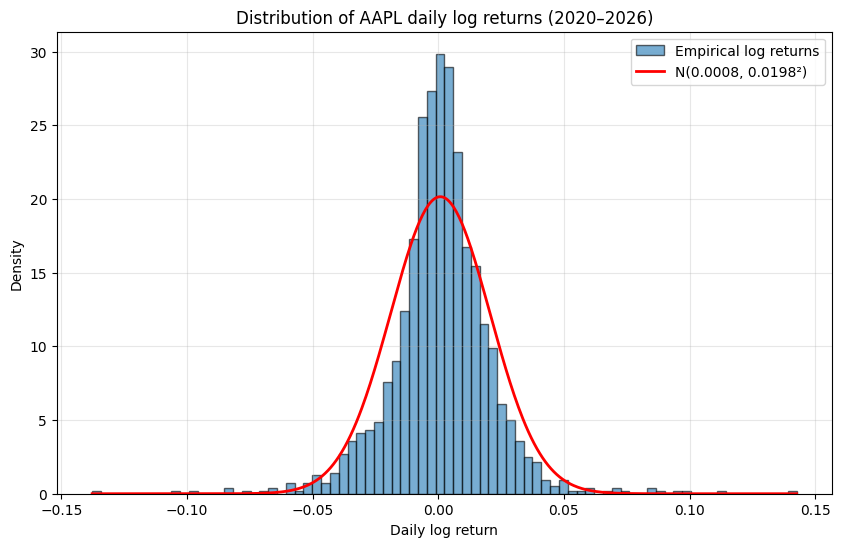

In [9]:
# Histogram with fitted normal density

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(aapl_log_return, bins=80, density=True,
        alpha=0.6, edgecolor="black", label="Empirical log returns")

x = np.linspace(aapl_log_return.min(), aapl_log_return.max(), 500)
ax.plot(x, norm.pdf(x, mu_daily, sigma_daily),
        "r-", lw=2, label=f"N({mu_daily:.4f}, {sigma_daily:.4f}²)")

ax.set_title("Distribution of AAPL daily log returns (2020–2026)")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Binomial Model

#### Binomial Model Assumptions
- T = 6 months
- n = 25 steps
- r = 1% p.a.
- $S_0$ = AAPL price on 28 April 2026
- u = $e^{(\sigma \sqrt{\delta t})} $, d = 1/u,
-  p = 1/2

#### Standard deviation $\sigma$

In [10]:
# using sigma daily defined earlier:
sigma = sigma_daily * np.sqrt(250)

print(f"Daily volatility:       {sigma_daily:.6f}")
print(f"Annualized volatility:  {sigma:.6f}  ({sigma*100:.2f}%)")

Daily volatility:       0.019798
Annualized volatility:  0.313031  (31.30%)


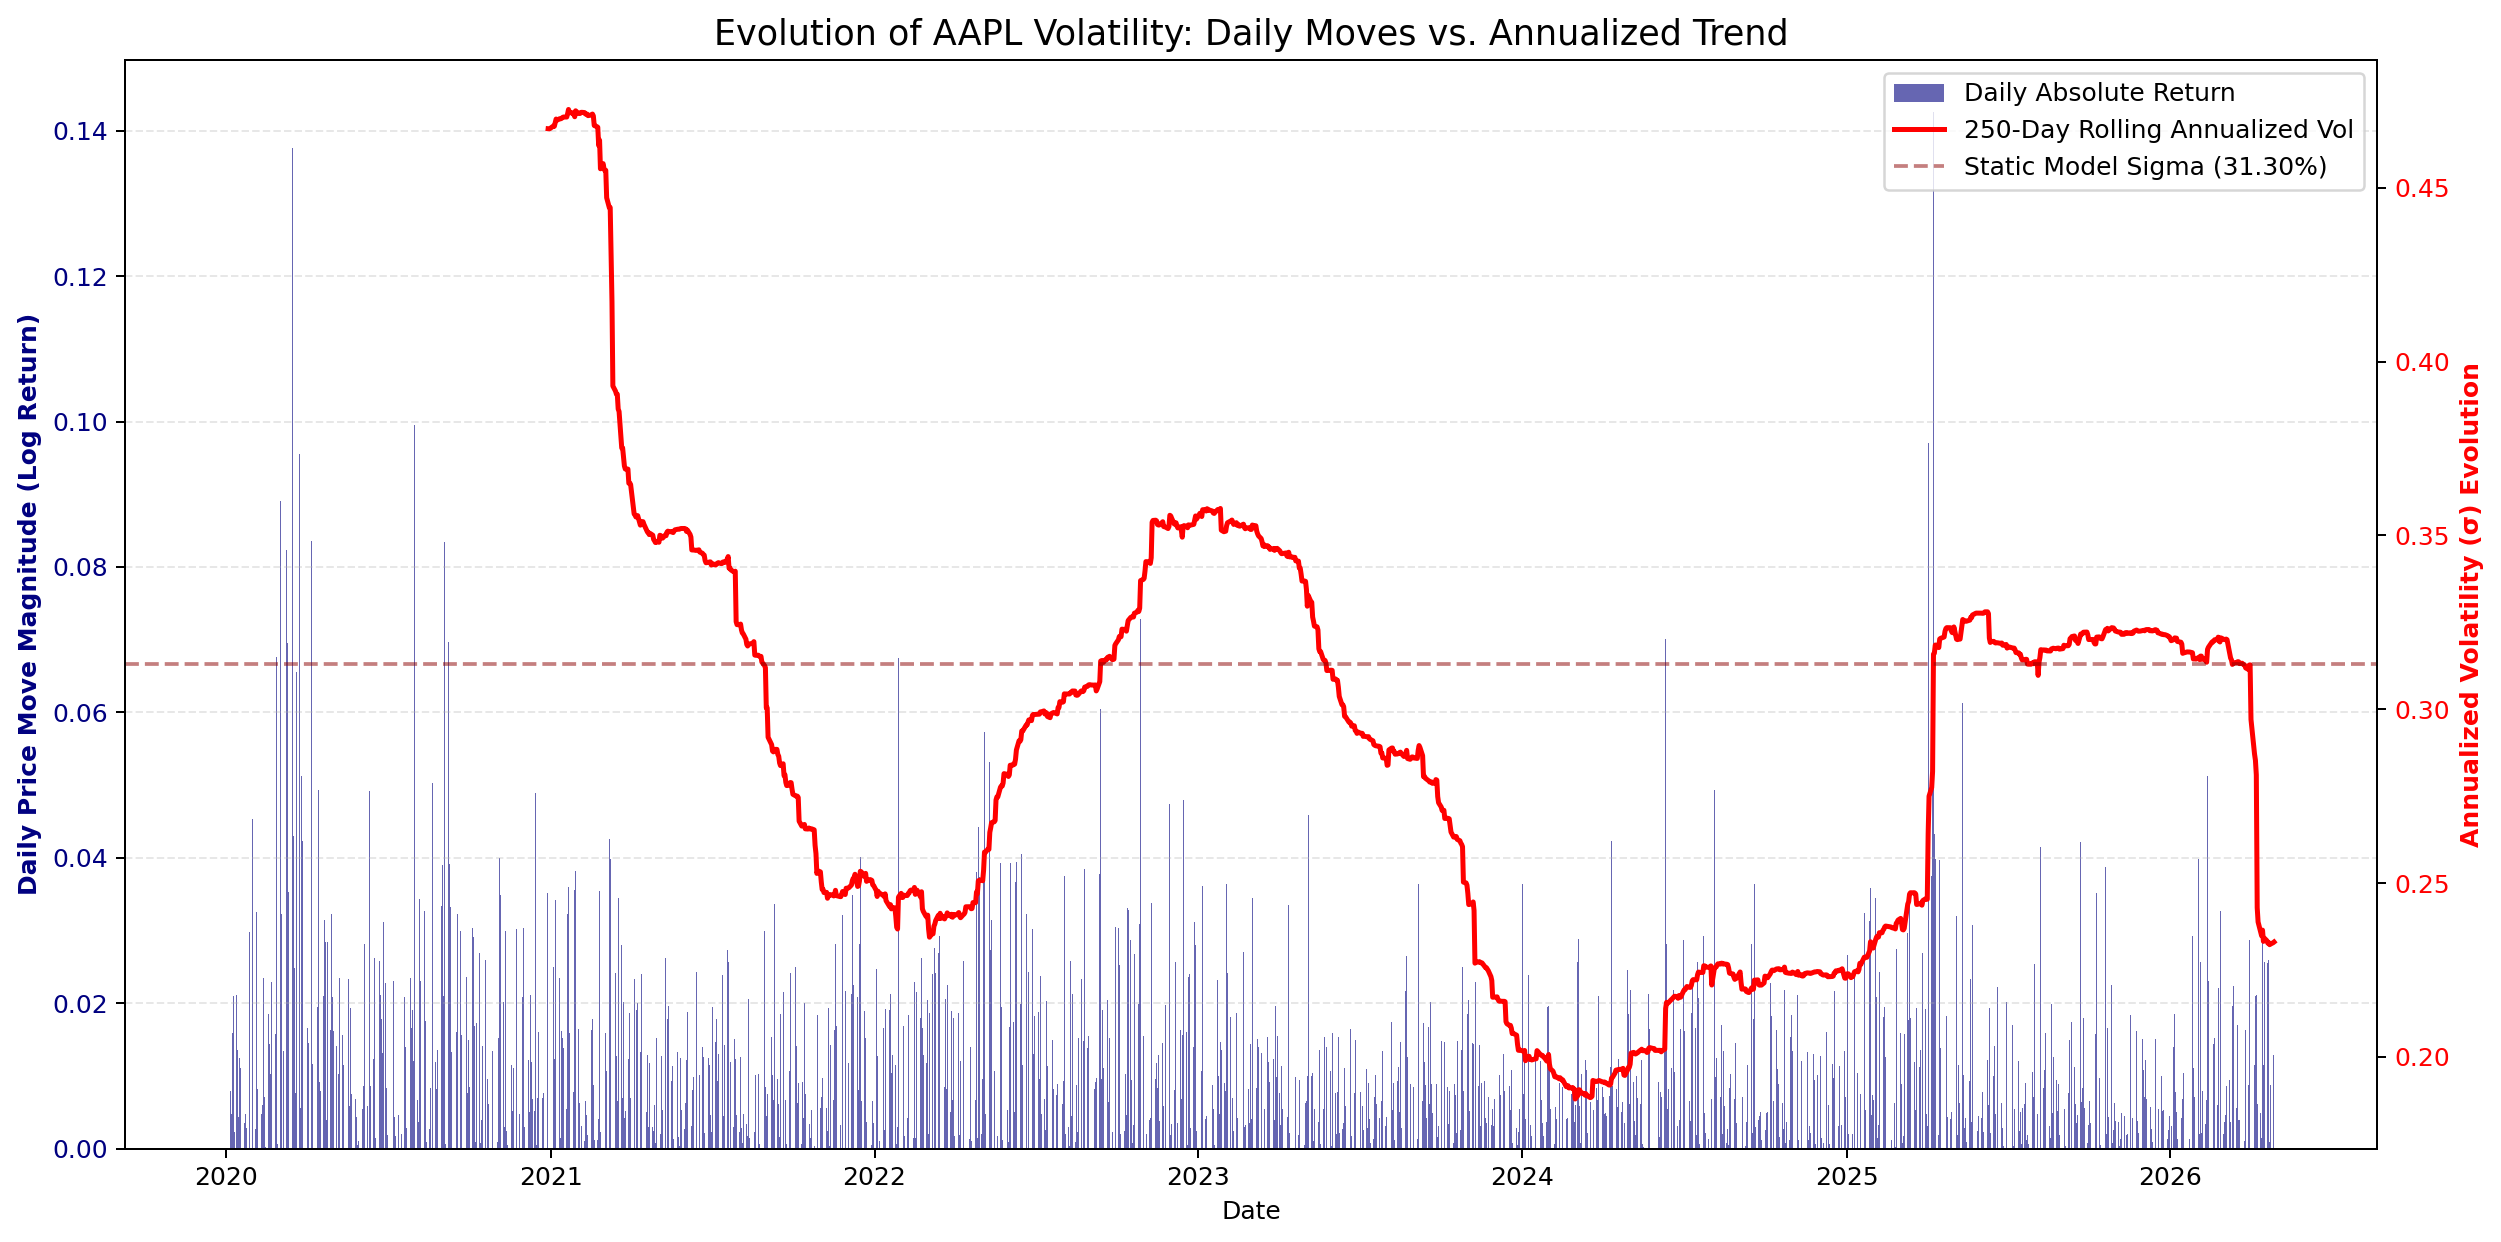

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate daily log-returns and their absolute magnitude
aapl_prices['Log_Return'] = np.log(aapl_prices['AAPL'] / aapl_prices['AAPL'].shift(1))
aapl_prices['Daily_Abs_Return'] = aapl_prices['Log_Return'].abs()

# 2. Calculate Rolling Annualized Volatility
# We use a 21-day window (roughly one trading month) to see the evolution
window = 250
aapl_prices['Rolling_Ann_Vol'] = aapl_prices['Log_Return'].rolling(window=window).std() * np.sqrt(250)

# 3. Setup the plot
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=180)

# Plot Daily Volatility (Navy Blue Bars)
ax1.bar(aapl_prices.index, aapl_prices['Daily_Abs_Return'], 
        color='navy', label='Daily Absolute Return', alpha=0.6)
ax1.set_ylabel('Daily Price Move Magnitude (Log Return)', color='navy', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='navy')

# 4. Create secondary axis for the Evolution of Annualized Volatility (Red Line)
ax2 = ax1.twinx()
ax2.plot(aapl_prices.index, aapl_prices['Rolling_Ann_Vol'], 
         color='red', linewidth=2, label=f'{window}-Day Rolling Annualized Vol')
ax2.set_ylabel('Annualized Volatility (σ) Evolution', color='red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal dashed line for the single 'sigma' used in your model for comparison
ax2.axhline(y=sigma, color='darkred', linestyle='--', alpha=0.5, label='Static Model Sigma (31.30%)')

# Formatting
plt.title('Evolution of AAPL Volatility: Daily Moves vs. Annualized Trend', fontsize=14)
ax1.set_xlabel('Date')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.tight_layout()
plt.show()

#### Define tree parameters

In [11]:
T  = 0.5
n  = 25
r  = 0.01
dt = T / n

u = np.exp(sigma * np.sqrt(dt))
d = 1 / u                              # = np.exp(-sigma*np.sqrt(dt))
q = (np.exp(r*dt) - d) / (u - d)       # risk-neutral probability

S0 = float(aapl_prices.loc["2026-04-28", "AAPL"])

print(f"S0  = {S0:.4f}")
print(f"dt  = {dt:.6f}")
print(f"u   = {u:.6f}")
print(f"d   = {d:.6f}")
print(f"q   = {q:.6f}   (no-arb requires 0 < q < 1)")
assert 0 < q < 1, "No-arbitrage condition violated"

S0  = 270.4608
dt  = 0.020000
u   = 1.045264
d   = 0.956696
q   = 0.491193   (no-arb requires 0 < q < 1)


We calculated the risk-neutral probability q as $\frac{e^{r \Delta t} - d}{u - d}$, resulting in a value of $q \approx 0.491$. The binomial tree below is constructed using the real-world probability $p = 1/2$ while the pricing will be done using the risk-neutral probability q.

### Pricing with a binomial model

In [ ]:
def price_asian_floating(S0, sigma, r, T, n, return_terminals=False):
    """
    Price a European floating-strike Asian call via an augmented
    (S_t, C_t) binomial tree with backward induction.

    Returns the price at t=0. Optionally returns terminal payoffs
    for diagnostics.
    """
    dt   = T / n # length of one tree step in years
    u    = np.exp(sigma * np.sqrt(dt)) # up factor
    d    = 1.0 / u # down factor
    q    = (np.exp(r * dt) - d) / (u - d) # risk neutral probability
    disc = np.exp(-r * dt) # per-step discount factor
    assert 0 < q < 1, "No-arbitrage condition violated" # check no-arbitrage holds

    # Forward pass: build all 2^n terminal (S_n, C_n) pairs
    # Ordering convention: at each step, the "up" child is appended before the "down" child. This guarantees that after all n steps,
    # consecutive pairs (2k, 2k+1) at any level share the same parent, which we exploit in the backward pass.

    states = [(S0, S0)] # states is a list of tuples: each tuple is one path's current state                # t = 0: C_0 = S_0
    for _ in range(n):
        new_states = []
        for S, C in states:
            S_up = S * u
            S_dn = S * d
            new_states.append((S_up, C + S_up))   # up child first
            new_states.append((S_dn, C + S_dn))   # down child second
        states = new_states # replace old states with new ones: list is now longer

    # Terminal payoffs A_T = max(S_n - C_n/(n+1), 0) 
    payoffs = np.array(
        [max(S - C / (n + 1), 0.0) for S, C in states]
    )

    # Backward induction 
    # At each step, pair up siblings: even index = up child, odd = down child.
    # V_parent = e^(-r dt) [ q V_up + (1-q) V_down ]
    values = payoffs 
    for _ in range(n):
        values = disc * (q * values[0::2] + (1.0 - q) * values[1::2]) # discounted risk-neutral expectation 

    price = float(values[0])
    if return_terminals:
        terminals = np.array([(S, C / (n + 1)) for S, C in states])
        return price, payoffs, terminals
    return price

### Binomial tree (taking into account tree recombination) 
--> therefore way faster ;)) 

In [12]:
def price_asian_floating(S0, sigma, r, T, n, return_terminals=False):
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u  # Recombining property: u * d = 1
    q    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    
    # Forward Pass: Recombining Node Structure
    # Instead of one giant list, we use a list of lists.
    # tree[t][j] will store a list of all possible cumulative sums at time t, node j.
    tree = [[[] for _ in range(t + 1)] for t in range(n + 1)]
    tree[0][0].append(S0)

    for t in range(n):
        for j in range(t + 1):
            # Calculate stock prices for the next step using the recombining property
            # node j -> Up child is (t+1, j+1), Down child is (t+1, j)
            S_next_up = S0 * (u**(j+1)) * (d**(t-j))
            S_next_dn = S0 * (u**j) * (d**(t+1-j))
            
            for C in tree[t][j]:
                tree[t+1][j+1].append(C + S_next_up)
                tree[t+1][j].append(C + S_next_dn)

    # Terminal Payoffs
    # We now calculate payoffs node by node
    values_tree = [[] for _ in range(n + 1)]
    for j in range(n + 1):
        Sn = S0 * (u**j) * (d**(n-j))
        for Cn in tree[n][j]:
            payoff = max(Sn - Cn / (n + 1), 0.0)
            values_tree[j].append(payoff)

    # Backward Induction
    # We work backwards through the nodes
    current_values = values_tree
    for t in range(n - 1, -1, -1):
        next_values = [[] for _ in range(t + 1)]
        for j in range(t + 1):
            # In a binary path structure, sums are paired by creation order.
            # Up child sums are in current_values[j+1], Down child sums in current_values[j].
            # Because we appended Up then Down in the forward pass, the order is preserved.
            n_sums = len(tree[t][j])
            up_sums = current_values[j+1][:n_sums]
            dn_sums = current_values[j][-n_sums:]
            
            for v_up, v_dn in zip(up_sums, dn_sums):
                next_values[j].append(disc * (q * v_up + (1 - q) * v_dn))
        current_values = next_values

    price = current_values[0][0]
    return price

In [13]:
### Run the code
t0 = time.time() # Just to see how long the model runs
price_A = price_asian_floating(S0, sigma, r, T, n)
t_A = time.time() - t0

print(f"Asian call price : {price_A:.6f}   [{t_A:.2f}s]")

Asian call price : 14.038219   [22.50s]


### Faster version (vectorized), for use later in the robustness grid

In [ ]:
def price_asian_floating_vectorized(S0, sigma, r, T, n, chunk_log2=20, verbose=False):
    """
    Vectorized + chunked pricer for the European floating-strike Asian call.

    Parameters
    ----------
    S0, sigma, r, T : floats
        Spot, annualized vol, risk-free rate, maturity (years).
    n : int
        Number of binomial steps.
    chunk_log2 : int
        log2 of the chunk size in paths. chunk_log2=20 -> 2^20 paths/chunk.
        Each chunk uses roughly 2^chunk_log2 * (n+1) * 8 bytes of RAM
        (e.g. ~220 MB for chunk_log2=20, n=25).
    verbose : bool
        If True, print progress per chunk.

    Returns
    -------
    price : float
        Arbitrage-free price at t = 0.
    """
    # Calibration (same as the explicit version)
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    q    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * T)             # full-horizon discount, applied once at the end
    assert 0 < q < 1, "No-arbitrage condition violated"

    log_u, log_d = np.log(u), np.log(d)
    log_q, log_1mq = np.log(q), np.log(1.0 - q)

    # Chunking setup 
    total_paths = 1 << n                              # 2^n
    chunk_size  = min(1 << chunk_log2, total_paths)
    n_chunks    = total_paths // chunk_size

    # We accumulate the (undiscounted) Q-expected payoff in `running`.
    # Using log-space weights avoids underflow when q^k * (1-q)^(n-k)
    # gets very small for paths with extreme k.
    running_sum = 0.0

    # Pre-compute per-step bit positions (most significant bit = step 1)
    bit_positions = np.arange(n - 1, -1, -1, dtype=np.int64)

    t_start = time.time()
    for c in range(n_chunks):
        # ---- Generate this chunk's path indices ----
        idx = np.arange(c * chunk_size,
                        (c + 1) * chunk_size,
                        dtype=np.int64)[:, None]                 # (chunk, 1)

        # Decode each path index into n bits: 0 = up, 1 = down
        # (matches the "up-child first" ordering of the explicit version)
        bits = ((idx >> bit_positions) & 1).astype(np.int8)      # (chunk, n)

        # Number of up-moves per path (needed for risk-neutral weights)
        k = (bits == 0).sum(axis=1)                              # (chunk,)

        # Build price paths in log space 
        # log-step at each (path, t) = log_u if bit=0 else log_d
        log_steps = np.where(bits == 0, log_u, log_d)            # (chunk, n)

        # Cumulative log-prices, prepend log(S0) for t=0
        log_S = np.empty((bits.shape[0], n + 1))
        log_S[:, 0]  = np.log(S0)
        log_S[:, 1:] = np.log(S0) + np.cumsum(log_steps, axis=1)

        S_paths = np.exp(log_S)                                  # (chunk, n+1)

        # Payoff per path
        S_n     = S_paths[:, -1]
        S_bar_n = S_paths.mean(axis=1)                           # = C_n / (n+1)
        payoff  = np.maximum(S_n - S_bar_n, 0.0)                 # (chunk,)

        # Risk-neutral weights (in log-space for stability)
        log_w = k * log_q + (n - k) * log_1mq                    # (chunk,)
        w     = np.exp(log_w)                                    # (chunk,)

        # Accumulate
        running_sum += float((w * payoff).sum())

        if verbose and (c % max(1, n_chunks // 10) == 0 or c == n_chunks - 1):
            elapsed = time.time() - t_start
            print(f"  chunk {c+1:>4}/{n_chunks}  "
                  f"running E_Q[A_T] ≈ {running_sum:.6f}  "
                  f"[{elapsed:.1f}s]")

    # Final price
    price = disc * running_sum
    return price

In [ ]:
# Here we run the vectorized version, which is a bit faster, and make sure it gives the same output as the explicit one
print("Running vectorized version...")
t0 = time.time()
price_V = price_asian_floating_vectorized(S0, sigma, r, T, n,
                                          chunk_log2=20, verbose=True)
t_V = time.time() - t0

print(f"\nAsian call price (vectorized) : {price_V:.6f}   [{t_V:.2f}s]")
print(f"Asian call price (explicit)   : {price_A:.6f}")
print(f"Absolute difference           : {abs(price_V - price_A):.2e}")

Running vectorized version...
  chunk    1/32  running E_Q[A_T] ≈ 0.614574  [2.6s]
  chunk    4/32  running E_Q[A_T] ≈ 2.076905  [9.9s]
  chunk    7/32  running E_Q[A_T] ≈ 3.515365  [14.9s]
  chunk   10/32  running E_Q[A_T] ≈ 4.894342  [18.9s]
  chunk   13/32  running E_Q[A_T] ≈ 6.229844  [23.6s]
  chunk   16/32  running E_Q[A_T] ≈ 7.355276  [26.8s]
  chunk   19/32  running E_Q[A_T] ≈ 8.877630  [30.2s]
  chunk   22/32  running E_Q[A_T] ≈ 10.176375  [33.3s]
  chunk   25/32  running E_Q[A_T] ≈ 11.444933  [36.7s]
  chunk   28/32  running E_Q[A_T] ≈ 12.646303  [40.5s]
  chunk   31/32  running E_Q[A_T] ≈ 13.824871  [44.7s]
  chunk   32/32  running E_Q[A_T] ≈ 14.121580  [45.9s]

Asian call price (vectorized) : 14.051149   [45.98s]
Asian call price (explicit)   : 14.051149
Absolute difference           : 5.51e-14


### Robustness checks

In [ ]:
def price_robust(S0, sigma, r, T, n):
    return price_asian_floating_vectorized(
        S0, sigma, r, T, n, chunk_log2=22, verbose=False
    )

# Define grids
# r: bracket the assignment's 1% with realistic alternatives (zero rates,
# pre-COVID levels, current levels, hiking-cycle levels)
r_grid = np.array([0.000, 0.005, 0.010, 0.020, 0.030, 0.040])

# sigma: ±30% around the calibrated value, plus the calibrated point itself
sigma_multipliers = np.array([0.70, 0.85, 1.00, 1.15, 1.30])
sigma_grid = sigma * sigma_multipliers

print(f"Calibrated sigma = {sigma:.4f}")
print(f"Sigma grid       = {sigma_grid.round(4)}")
print(f"r grid           = {r_grid}")
print(f"\nTotal evaluations: {len(sigma_grid) * len(r_grid)} "
      f"(~{len(sigma_grid)*len(r_grid)*45/60:.0f} min)\n")


Calibrated sigma = 0.3130
Sigma grid       = [0.2191 0.2661 0.313  0.36   0.4069]
r grid           = [0.    0.005 0.01  0.02  0.03  0.04 ]

Total evaluations: 30 (~22 min)



In [ ]:
# Run the grid 
results = np.zeros((len(sigma_grid), len(r_grid)))

t_total = time.time()
for i, s in enumerate(sigma_grid):
    for j, rate in enumerate(r_grid):
        t0 = time.time()
        results[i, j] = price_robust(S0, s, rate, T, n)
        print(f"  σ={s:.4f} (×{sigma_multipliers[i]:.2f}), r={rate:.3f}: "
              f"price = {results[i,j]:7.4f}   [{time.time()-t0:.1f}s]")

print(f"\nTotal grid runtime: {(time.time()-t_total)/60:.1f} min")

  σ=0.2191 (×0.70), r=0.000: price =  9.6194   [62.0s]
  σ=0.2191 (×0.70), r=0.005: price =  9.7815   [37.3s]
  σ=0.2191 (×0.70), r=0.010: price =  9.9451   [45.3s]
  σ=0.2191 (×0.70), r=0.020: price = 10.2769   [42.4s]
  σ=0.2191 (×0.70), r=0.030: price = 10.6150   [65.2s]
  σ=0.2191 (×0.70), r=0.040: price = 10.9593   [33.6s]
  σ=0.2661 (×0.85), r=0.000: price = 11.6774   [54.9s]
  σ=0.2661 (×0.85), r=0.005: price = 11.8375   [31.7s]
  σ=0.2661 (×0.85), r=0.010: price = 11.9990   [43.2s]
  σ=0.2661 (×0.85), r=0.020: price = 12.3255   [32.0s]
  σ=0.2661 (×0.85), r=0.030: price = 12.6570   [36.8s]
  σ=0.2661 (×0.85), r=0.040: price = 12.9934   [41.6s]
  σ=0.3130 (×1.00), r=0.000: price = 13.7334   [42.4s]
  σ=0.3130 (×1.00), r=0.005: price = 13.8918   [41.7s]
  σ=0.3130 (×1.00), r=0.010: price = 14.0511   [32.1s]
  σ=0.3130 (×1.00), r=0.020: price = 14.3730   [40.4s]
  σ=0.3130 (×1.00), r=0.030: price = 14.6988   [42.9s]
  σ=0.3130 (×1.00), r=0.040: price = 15.0287   [40.7s]
  σ=0.3600

In [ ]:
# Put the results in a dataframe and then save it as a csv for later use
df_prices = pd.DataFrame(
    results,
    index=[f"{m:.2f}σ̂  ({s:.4f})" for m, s in zip(sigma_multipliers, sigma_grid)],
    columns=[f"r={r:.3f}" for r in r_grid],
)
df_prices.index.name = "Volatility"
print("\nFloating-strike Asian call price (USD):")
print(df_prices.round(4).to_string())

# Save for the report
df_prices.round(4).to_csv("data/robustness_grid.csv")


Floating-strike Asian call price (USD):
                  r=0.000  r=0.005  r=0.010  r=0.020  r=0.030  r=0.040
Volatility                                                            
0.70σ̂  (0.2191)   9.6194   9.7815   9.9451  10.2769  10.6150  10.9593
0.85σ̂  (0.2661)  11.6774  11.8375  11.9990  12.3255  12.6570  12.9934
1.00σ̂  (0.3130)  13.7334  13.8918  14.0511  14.3730  14.6988  15.0287
1.15σ̂  (0.3600)  15.7872  15.9437  16.1012  16.4186  16.7395  17.0636
1.30σ̂  (0.4069)  17.8383  17.9932  18.1487  18.4620  18.7782  19.0972


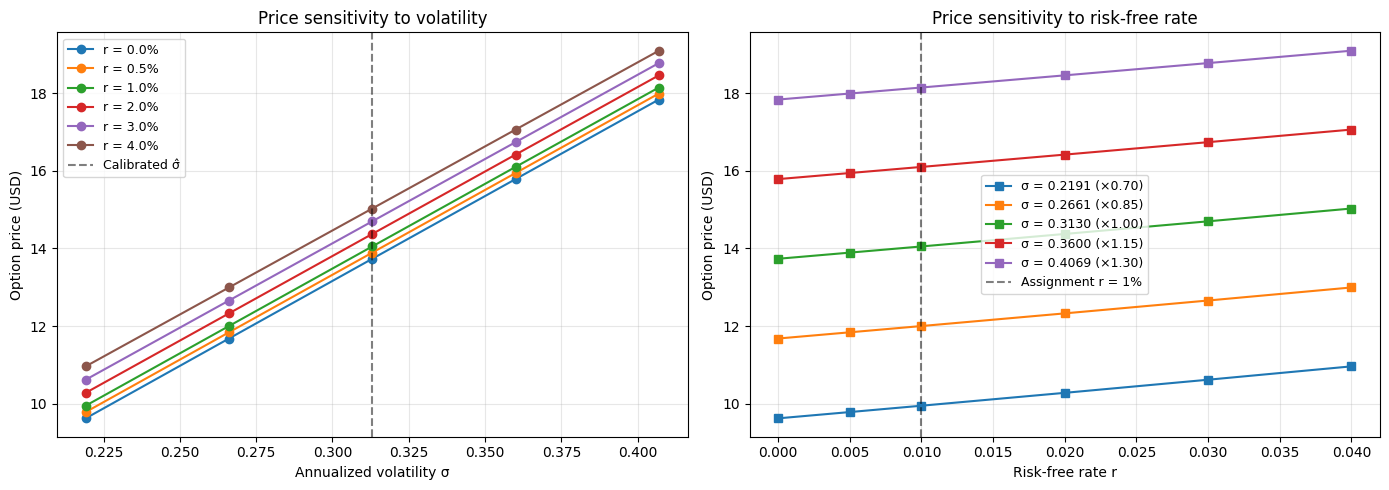

In [ ]:
# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: price vs sigma, one line per r
for j, rate in enumerate(r_grid):
    ax1.plot(sigma_grid, results[:, j],
             marker="o", label=f"r = {rate:.1%}")
ax1.axvline(sigma, color="black", ls="--", alpha=0.5, label="Calibrated σ̂")
ax1.set_xlabel("Annualized volatility σ")
ax1.set_ylabel("Option price (USD)")
ax1.set_title("Price sensitivity to volatility")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Right panel: price vs r, one line per sigma
for i, s in enumerate(sigma_grid):
    ax2.plot(r_grid, results[i, :],
             marker="s", label=f"σ = {s:.4f} (×{sigma_multipliers[i]:.2f})")
ax2.axvline(0.01, color="black", ls="--", alpha=0.5, label="Assignment r = 1%")
ax2.set_xlabel("Risk-free rate r")
ax2.set_ylabel("Option price (USD)")
ax2.set_title("Price sensitivity to risk-free rate")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/robustness_check.png", dpi=150, bbox_inches="tight")
plt.show()

### Greeks

In [ ]:
def compute_greeks(price_fn, S0, sigma, r, T, n,
                   h_S_rel=0.01,    # 1% of S0
                   h_sigma=0.01,    # 1 vol point
                   h_r=0.005,       # 50 bps
                   h_T_rel=0.01):   # 1% of T
    """
    Finite-difference Greeks for the floating-strike Asian call.
    
    Uses central differences for first-order Greeks (O(h^2) accurate),
    second central differences for gammas/volga, and a four-point stencil
    for the cross-derivative (vanna). All bumps are absolute except for
    S0 and T, where relative bumps avoid sign-change and rescale issues.
    
    price_fn must have signature (S0, sigma, r, T, n) -> float.
    """
    h_S = S0 * h_S_rel
    h_T = T  * h_T_rel
    
    # ---- Baseline ----
    V0 = price_fn(S0, sigma, r, T, n)
    
    # ---- First-order in S: delta, and the points we'll reuse for gamma ----
    V_S_up   = price_fn(S0 + h_S, sigma, r, T, n)
    V_S_down = price_fn(S0 - h_S, sigma, r, T, n)
    delta = (V_S_up - V_S_down) / (2 * h_S)
    gamma = (V_S_up - 2*V0 + V_S_down) / h_S**2
    
    # ---- First-order in sigma: vega and volga ----
    V_sig_up   = price_fn(S0, sigma + h_sigma, r, T, n)
    V_sig_down = price_fn(S0, sigma - h_sigma, r, T, n)
    vega  = (V_sig_up - V_sig_down) / (2 * h_sigma)
    volga = (V_sig_up - 2*V0 + V_sig_down) / h_sigma**2
    
    # ---- Cross derivative: vanna = d(delta)/d(sigma) = d(vega)/dS ----
    # Four corners of an (S, sigma) box, central difference
    V_pp = price_fn(S0 + h_S, sigma + h_sigma, r, T, n)
    V_pm = price_fn(S0 + h_S, sigma - h_sigma, r, T, n)
    V_mp = price_fn(S0 - h_S, sigma + h_sigma, r, T, n)
    V_mm = price_fn(S0 - h_S, sigma - h_sigma, r, T, n)
    vanna = (V_pp - V_pm - V_mp + V_mm) / (4 * h_S * h_sigma)
    
    # ---- Rho ----
    V_r_up   = price_fn(S0, sigma, r + h_r, T, n)
    V_r_down = price_fn(S0, sigma, r - h_r, T, n)
    rho = (V_r_up - V_r_down) / (2 * h_r)
    
    # ---- Theta: convention is dV/dt = -dV/dT (time passing = T shrinking) ----
    # NB: bumping T also bumps dt = T/n. That's the standard "calendar theta".
    V_T_up   = price_fn(S0, sigma, r, T + h_T, n)
    V_T_down = price_fn(S0, sigma, r, T - h_T, n)
    theta = -(V_T_up - V_T_down) / (2 * h_T)
    
    return {
        'price': V0,
        'delta': delta,    # dV/dS0
        'gamma': gamma,    # d2V/dS0^2
        'vega':  vega,     # dV/dsigma
        'volga': volga,    # d2V/dsigma^2
        'vanna': vanna,    # d2V/dS0 dsigma
        'rho':   rho,      # dV/dr
        'theta': theta,    # -dV/dT
    }

In [ ]:
# ---- Run it ----
greeks = compute_greeks(price_robust, S0, sigma, r, T, n)

# ---- Pretty print with practitioner shocks ----
print(f"\n--- Greeks at baseline (S0={S0:.2f}, sigma={sigma:.4f}, r={r:.3f}, T={T}) ---")
print(f"Baseline price        : {greeks['price']:10.4f}")
print(f"Delta  (dV/dS0)       : {greeks['delta']:10.6f}")
print(f"  -> for +$1 in S0    : Delta_V = {greeks['delta']:.4f}")
print(f"Gamma  (d2V/dS0^2)    : {greeks['gamma']:10.6e}")
print(f"  -> for +$1 in S0    : Delta_Delta = {greeks['gamma']:.6f}")
print(f"Vega   (dV/dsigma)    : {greeks['vega']:10.4f}")
print(f"  -> for +1 vol pt    : Delta_V = {greeks['vega']*0.01:.4f}")
print(f"Volga  (d2V/dsigma^2) : {greeks['volga']:10.4f}")
print(f"  -> for +1 vol pt    : Delta_Vega = {greeks['volga']*0.01:.4f}")
print(f"Vanna  (d2V/dS dsig)  : {greeks['vanna']:10.6f}")
print(f"  -> for +1 vol pt    : Delta_Delta = {greeks['vanna']*0.01:.6f}")
print(f"Rho    (dV/dr)        : {greeks['rho']:10.4f}")
print(f"  -> for +1pp in r    : Delta_V = {greeks['rho']*0.01:.4f}")
print(f"Theta  (-dV/dT, /yr)  : {greeks['theta']:10.4f}")
print(f"  -> per calendar day : Delta_V = {greeks['theta']/365:.4f}")

# ---- Sanity checks specific to this product ----
print(f"\n--- Sanity checks (linearity of payoff in S0) ---")
print(f"Delta vs V/S0      : {greeks['delta']:.6f} vs {greeks['price']/S0:.6f}  (should match exactly)")
print(f"Gamma              : {greeks['gamma']:.3e}             (should be ~0; floor is FD noise)")
print(f"Vanna vs Vega/S0   : {greeks['vanna']:.6f} vs {greeks['vega']/S0:.6f}  (should match)")


--- Greeks at baseline (S0=270.71, sigma=0.3130, r=0.010, T=0.5) ---
Baseline price        :    14.0511
Delta  (dV/dS0)       :   0.051905
  -> for +$1 in S0    : Delta_V = 0.0519
Gamma  (d2V/dS0^2)    : 0.000000e+00
  -> for +$1 in S0    : Delta_Delta = 0.000000
Vega   (dV/dsigma)    :    43.6841
  -> for +1 vol pt    : Delta_V = 0.4368
Volga  (d2V/dsigma^2) :    -0.9256
  -> for +1 vol pt    : Delta_Vega = -0.0093
Vanna  (d2V/dS dsig)  :   0.161369
  -> for +1 vol pt    : Delta_Delta = 0.001614
Rho    (dV/dr)        :    31.9793
  -> for +1pp in r    : Delta_V = 0.3198
Theta  (-dV/dT, /yr)  :   -14.3142
  -> per calendar day : Delta_V = -0.0392

--- Sanity checks (linearity of payoff in S0) ---
Delta vs V/S0      : 0.051905 vs 0.051905  (should match exactly)
Gamma              : 0.000e+00             (should be ~0; floor is FD noise)
Vanna vs Vega/S0   : 0.161369 vs 0.161369  (should match)


### Normal Approximation

In [ ]:
def price_asian_normal_approx(S0, sigma, r, T, n, return_diagnostics=False):
    # ---- Input validation: fail fast with clear messages ----
    if not (S0 > 0):
        raise ValueError(f"S0 must be > 0, got {S0}")
    if sigma < 0:
        raise ValueError(f"sigma must be >= 0, got {sigma}")
    if not (T > 0):
        raise ValueError(f"T must be > 0, got {T}")
    if not (isinstance(n, (int, np.integer)) and n >= 1):
        raise ValueError(f"n must be a positive integer, got {n}")

    dt = T / n
    k  = np.arange(n + 1, dtype=float)            # 0, 1, ..., n

    # ---- First moments under Q (exact for the binomial too) ----
    # q is defined to enforce E^Q[S_{t+1}/S_t] = e^{r*dt}, hence
    # E^Q[S_k] = S_0 * exp(r*k*dt) by independence across steps.
    E_Sk    = S0 * np.exp(r * k * dt)             # shape (n+1,)
    mu_Sn   = E_Sk[-1]                             # E^Q[S_n] = S_0 * e^{rT}
    mu_Sbar = E_Sk.mean()                          # E^Q[S_bar_n]
    mu_D    = mu_Sn - mu_Sbar                      # E^Q[D_n]

    # ---- Edge case: sigma = 0 (deterministic stock path) ----
    # Then S_t = S_0 * e^{r*t*dt} for all t, so D_n = mu_D with zero variance.
    if sigma == 0.0:
        E_payoff = max(mu_D, 0.0)
        price    = np.exp(-r * T) * E_payoff
        if return_diagnostics:
            return price, {
                'price': price, 'mu_D': mu_D, 'sigma_D': 0.0,
                'z': np.sign(mu_D) * np.inf if mu_D != 0 else 0.0,
                'E_payoff': E_payoff, 'E_Sn': mu_Sn, 'E_Sbar': mu_Sbar,
            }
        return price

    # ---- Second moments under Q (GBM limit), built as one (n+1)x(n+1) matrix ----
    # E^Q[S_j S_k] = S_0^2 * exp( r*(j+k)*dt + sigma^2 * min(j,k) * dt )
    J, K   = np.meshgrid(k, k, indexing='ij')      # both (n+1)x(n+1)
    E_SjSk = S0**2 * np.exp(r * (J + K) * dt + sigma**2 * np.minimum(J, K) * dt)

    E_Sn2     = E_SjSk[-1, -1]                     # j = k = n
    E_Sn_Sbar = E_SjSk[-1, :].mean()               # row-avg = E[S_n * S_bar_n]
    E_Sbar2   = E_SjSk.mean()                       # full-avg = E[S_bar_n^2]

    # ---- Variance of D_n ----
    # Var(D_n) = E[D_n^2] - mu_D^2,  with
    # E[D_n^2] = E[S_n^2] - 2 E[S_n S_bar] + E[S_bar^2].
    E_Dn2 = E_Sn2 - 2.0 * E_Sn_Sbar + E_Sbar2
    var_D = E_Dn2 - mu_D**2

    # Floating-point safety: tiny-negative variance can occur from roundoff
    # when the true variance is small but positive. Clamp to 0 if within
    # tolerance; otherwise raise (would indicate a real bug).
    fp_tol = 1e-10 * max(mu_D**2, 1.0)
    if var_D < -fp_tol:
        raise RuntimeError(
            f"Variance of D_n computed as {var_D:.3e}, more negative than "
            f"floating-point tolerance ({-fp_tol:.1e}). Inputs may be invalid."
        )
    sigma_D = np.sqrt(max(var_D, 0.0))

    # ---- Closed-form expectation of the positive part of a normal RV ----
    # If D ~ N(mu, sigma^2), sigma > 0:
    #   E[max(D, 0)] = mu * Phi(z) + sigma * phi(z),  z = mu/sigma
    z        = mu_D / sigma_D
    E_payoff = mu_D * norm.cdf(z) + sigma_D * norm.pdf(z)
    price    = np.exp(-r * T) * E_payoff

    if return_diagnostics:
        return price, {
            'price': price, 'mu_D': mu_D, 'sigma_D': sigma_D, 'z': z,
            'E_payoff': E_payoff, 'E_Sn': mu_Sn, 'E_Sbar': mu_Sbar,
        }
    return price

In [ ]:
# Run the normal approximation for the assignment's parameters
price_N, diag_N = price_asian_normal_approx(S0, sigma, r, T, n,
                                            return_diagnostics=True)

print("Normal approximation diagnostics (under Q):")
print(f"  E^Q[S_n]      = {diag_N['E_Sn']:.4f}")
print(f"  E^Q[S̄_n]      = {diag_N['E_Sbar']:.4f}")
print(f"  μ_D           = {diag_N['mu_D']:.4f}")
print(f"  σ_D           = {diag_N['sigma_D']:.4f}")
print(f"  z = μ_D/σ_D   = {diag_N['z']:.4f}")
print(f"  E[max(D,0)]   = {diag_N['E_payoff']:.4f}")
print()
print(f"Normal approximation price : {price_N:.6f}")
print(f"Binomial (exact) price     : {price_A:.6f}")
print(f"Absolute error             : {price_N - price_A:+.6f}")
print(f"Relative error             : {(price_N / price_A - 1) * 100:+.3f}%")

Normal approximation diagnostics (under Q):
  E^Q[S_n]      = 272.0669
  E^Q[S̄_n]      = 271.3879
  μ_D           = 0.6790
  σ_D           = 35.0893
  z = μ_D/σ_D   = 0.0194
  E[max(D,0)]   = 14.3407

Normal approximation price : 14.269219
Binomial (exact) price     : 14.051149
Absolute error             : +0.218070
Relative error             : +1.552%


     n     Normal approx price
--------------------------------
    25               14.269219
    50               14.336857
   100               14.371522
   250               14.392601
   500               14.399675
  1000               14.403221


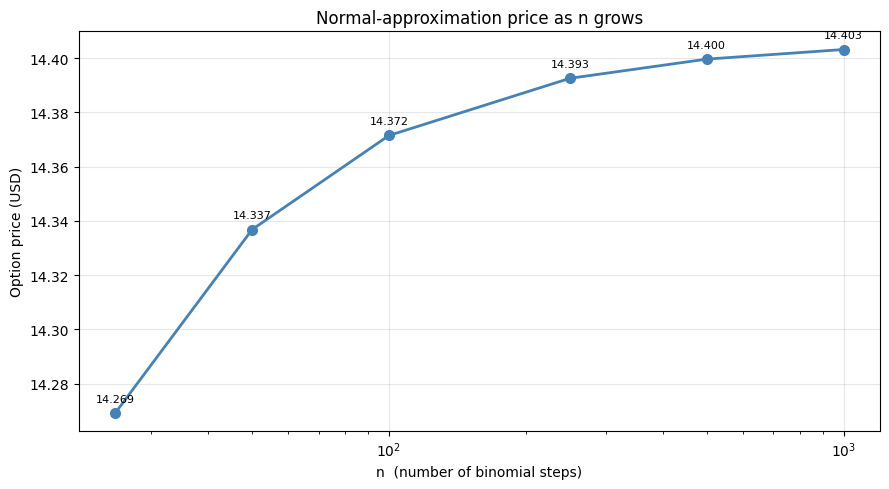

In [ ]:
# Convergence of the normal approximation as n grows.
# The approximation is justified by the CLT in the limit n -> infinity, so
# the price should stabilize as n increases.

n_values = [25, 50, 100, 250, 500, 1000]
prices_N_conv = np.array([
    price_asian_normal_approx(S0, sigma, r, T, n_c) for n_c in n_values
])

# Print the table
print(f"{'n':>6}  {'Normal approx price':>22}")
print("-" * 32)
for n_c, p in zip(n_values, prices_N_conv):
    print(f"{n_c:>6}  {p:>22.6f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_values, prices_N_conv, "o-", color="steelblue", lw=2, markersize=7)
ax.set_xscale("log")
ax.set_xlabel("n  (number of binomial steps)")
ax.set_ylabel("Option price (USD)")
ax.set_title("Normal-approximation price as n grows")
ax.grid(alpha=0.3)

# Annotate each point with its value
for n_c, p in zip(n_values, prices_N_conv):
    ax.annotate(f"{p:.3f}", xy=(n_c, p), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("figures/normal_approx_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# Monte Carlo Simulation

In [3]:

# Parameters
S0    = 270.46          # AAPL price on 28 April 2026 (placeholder)
r     = 0.01           # risk-free rate (1% per annum)
sigma = 0.3131         # volatility (assumed)
q=0.0                 # dividend yield (assumed zero for simplicity)
T     = 0.5            # maturity in years (6 months)
n     = 200            # number of time steps (≈ trading days in 6 months)
M     = 500           # number of Monte Carlo paths
dt    = T / n

rng = np.random.default_rng(seed=42)


In [4]:
# Draw shocks: shape (M, n)
Z = rng.standard_normal((M, n))

# Log-increments of GBM under risk-neutral measure
log_increments = (r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# Cumulative sum along time axis -> log price path (excluding S0)
log_paths = np.cumsum(log_increments, axis=1)

# Build full price matrix of shape (M, n+1), with S0 in column 0
S_paths = np.empty((M, n + 1))
S_paths[:, 0]  = S0
S_paths[:, 1:] = S0 * np.exp(log_paths)

print("Paths shape:", S_paths.shape)   # (200, 127)

Paths shape: (500, 201)


In [ ]:
S_avg = S_paths.mean(axis=1)            # shape (M,)

print("First 5 path averages:", S_avg[:5])

First 5 path averages: [254.94288034 265.8485334  247.3588198  236.4124647  237.67837506]


In [6]:
# Terminal price of each path
S_terminal = S_paths[:, -1]             # shape (M,)

# Floating-strike Asian call payoff: max(S_T - mean, 0)
payoffs = np.maximum(S_terminal - S_avg, 0.0)

# Discounted Monte Carlo estimator
discounted = np.exp(-r * T) * payoffs
price = discounted.mean()
se    = discounted.std(ddof=1) / np.sqrt(M)

print(f"\nAsian floating-strike call price : {price:.4f}")
print(f"Standard error                   : {se:.4f}")
print(f"95% confidence interval          : [{price - 1.96*se:.4f}, {price + 1.96*se:.4f}]")



Asian floating-strike call price : 13.5077
Standard error                   : 1.1110
95% confidence interval          : [11.3301, 15.6853]


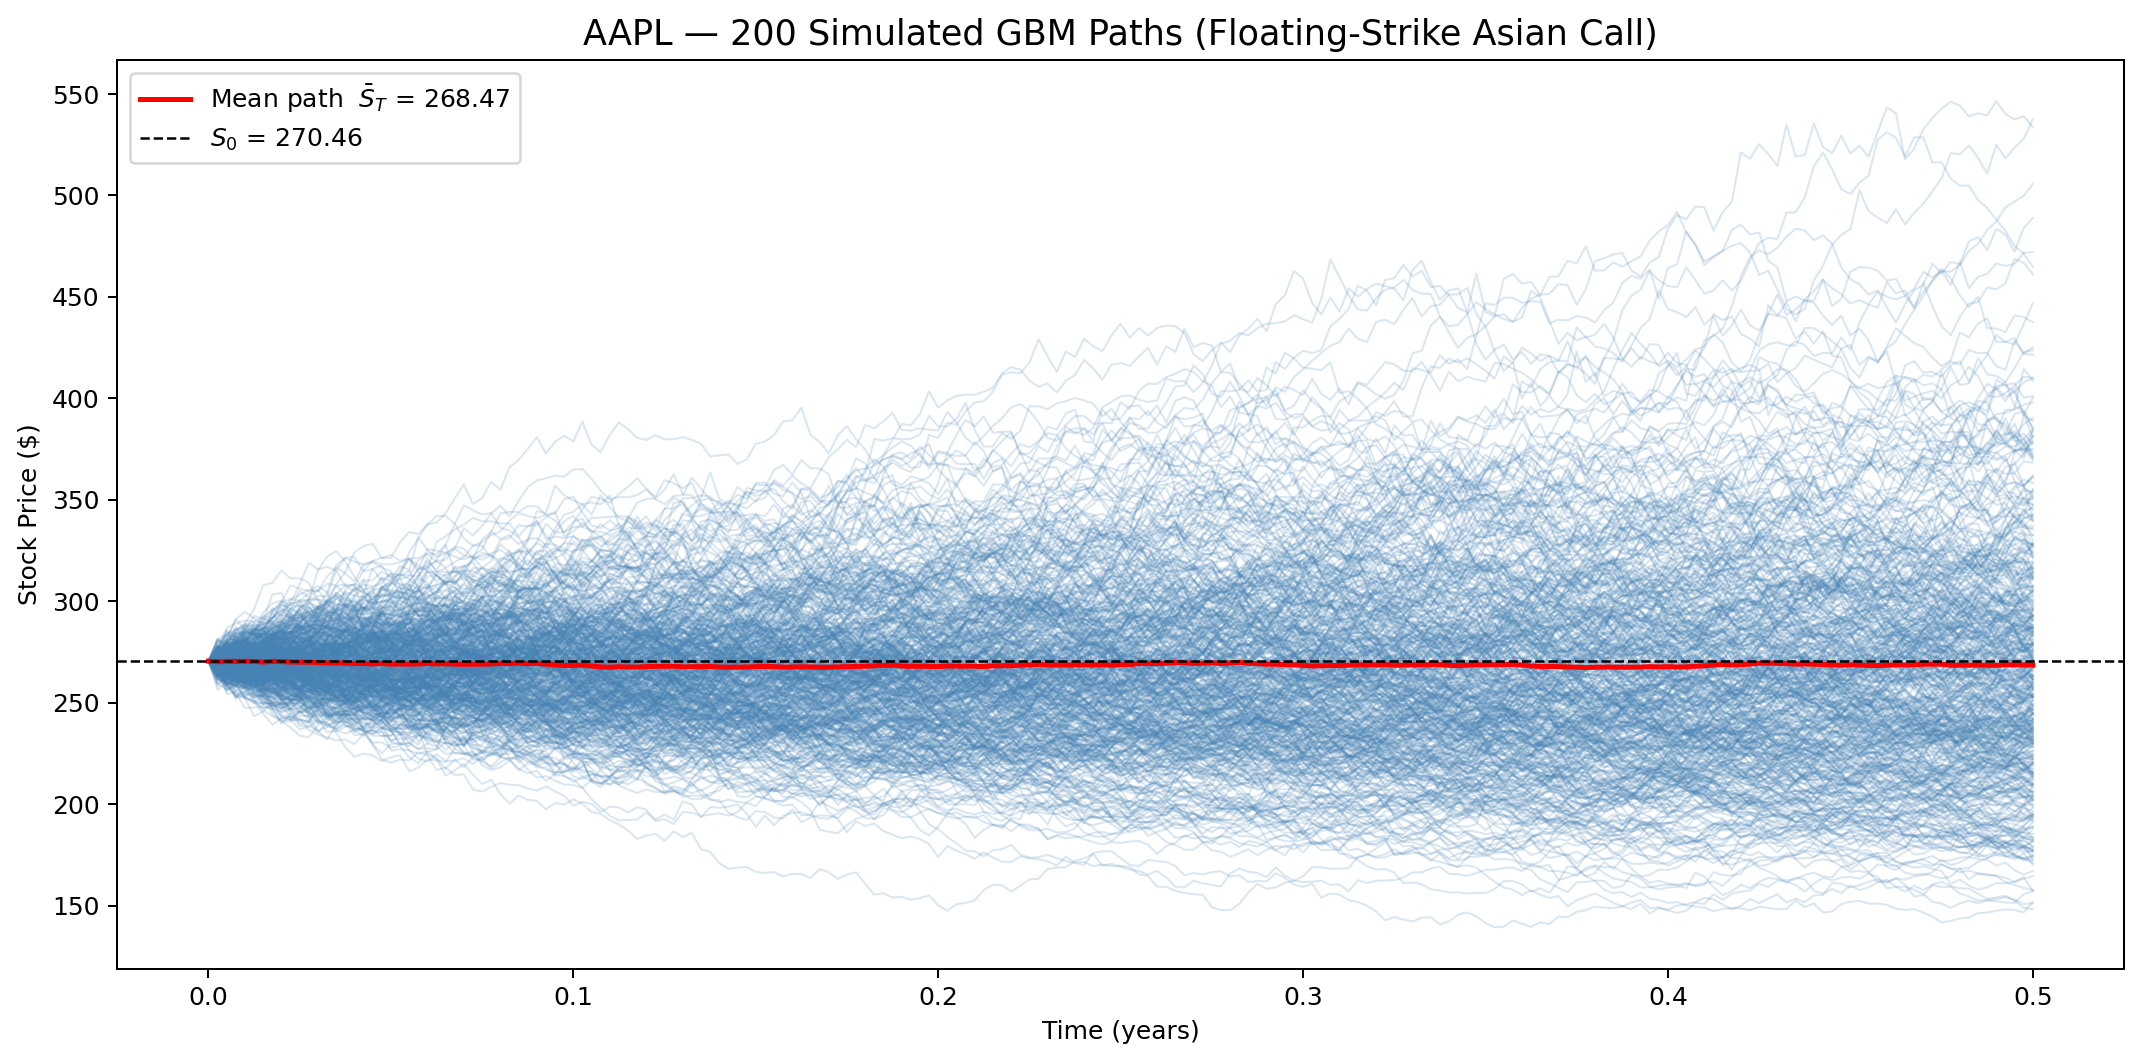

In [6]:
time_grid = np.linspace(0, T, n + 1)   # x-axis in years
plt.figure(figsize=(12, 6), dpi=180)

# All paths in light blue
for i in range(M):
    plt.plot(time_grid, S_paths[i], color="steelblue", alpha=0.2, linewidth=0.8)

# Mean path in red
mean_path = S_paths.mean(axis=0)
plt.plot(time_grid, mean_path, color="red", linewidth=2,
         label=f"Mean path  $\\bar{{S}}_T$ = {mean_path[-1]:.2f}")

# S0 reference line
plt.axhline(S0, color="black", linewidth=1, linestyle="--", label=f"$S_0$ = {S0}")

plt.title("AAPL — 200 Simulated GBM Paths (Floating-Strike Asian Call)", fontsize=14)
plt.xlabel("Time (years)")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from itertools import product

# =========================================================
# Parameters
# =========================================================
S0    = 270.46
r     = 0.01
q     = 0.0     
sigma = 0.3131
T     = 0.5

N_values = [10, 15, 20, 28, 35, 45, 50, 63, 75, 90, 100, 113,
            126, 150, 175, 210, 252, 275, 300, 350, 400, 450, 504, 550, 600]  # 24 points, max 550

M_values = [500, 750, 1000, 1500, 2000, 2500, 3500, 5000, 6000,
            7500, 9000, 10000, 12500, 15000, 17500, 20000, 27500,
            35000, 42500, 50000, 57500, 60000]                                   # 21 points, max 57500

print(f"Grid size : {len(N_values)} x {len(M_values)} = {len(N_values)*len(M_values)} runs")

# =========================================================
# Monte Carlo Loop
# =========================================================
results = []
total   = len(N_values) * len(M_values)

for idx, (n, M) in enumerate(product(N_values, M_values), 1):
    dt  = T / n
    rng = np.random.default_rng(seed=42)
    Z   = rng.standard_normal((M, n))

    log_increments = (r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    S_paths        = np.empty((M, n + 1))
    S_paths[:, 0]  = S0
    S_paths[:, 1:] = S0 * np.exp(np.cumsum(log_increments, axis=1))

    S_bar   = S_paths.mean(axis=1)
    ST      = S_paths[:, -1]
    payoffs = np.maximum(ST - S_bar, 0.0)
    price   = np.exp(-r * T) * payoffs.mean()

    results.append({"n": n, "M": M, "price": price})
    print(f"[{idx:>4}/{total}]  n={n:>4}  M={M:>6}  price={price:.4f}")

# =========================================================
# DataFrame + Pivot
# =========================================================
df    = pd.DataFrame(results)
pivot = df.pivot(index="n", columns="M", values="price")
print("\n", pivot.round(4))

# =========================================================
# Interactive Plotly Surface
# =========================================================
n_vals  = pivot.index.values          # y-axis  (time steps)
M_vals  = pivot.columns.values        # x-axis  (nb paths)
Z_surf  = pivot.values

fig = go.Figure(data=[go.Surface(
    x=np.log10(M_vals),               # log scale for M
    y=n_vals,
    z=Z_surf,
    colorscale="Viridis",
    colorbar=dict(title="Price ($)", thickness=18),
    hovertemplate=(
        "log₁₀(M): %{x:.2f}<br>"
        "n: %{y}<br>"
        "Price: $%{z:.4f}<extra></extra>"
    )
)])

# Proper x tick labels → show real M values
fig.update_layout(
    title=dict(
        text=(f"Floating-Strike Asian Call — MC Convergence<br>"
              f"<sup>AAPL  S₀={S0}  σ={sigma}  T={T}y  "
              f"r={r}  q={q}</sup>"),
        x=0.5
    ),
    scene=dict(
        xaxis=dict(
            title="M  [nb paths]",
            tickvals=np.log10(M_vals[::3]),
            ticktext=[str(m) for m in M_vals[::3]],
        ),
        yaxis=dict(title="n  [time steps]"),
        zaxis=dict(title="Asian Call Price ($)"),
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.8))   # default viewing angle
    ),
    width=1000,
    height=700,
    margin=dict(l=20, r=20, t=80, b=20)
)

fig.show()

# optional — save as standalone HTML
# fig.write_html("asian_surface.html")


Grid size : 25 x 22 = 550 runs
[   1/550]  n=  10  M=   500  price=13.0250
[   2/550]  n=  10  M=   750  price=13.3040
[   3/550]  n=  10  M=  1000  price=13.1972
[   4/550]  n=  10  M=  1500  price=13.1276
[   5/550]  n=  10  M=  2000  price=14.2013
[   6/550]  n=  10  M=  2500  price=14.4262
[   7/550]  n=  10  M=  3500  price=14.4463
[   8/550]  n=  10  M=  5000  price=13.9767
[   9/550]  n=  10  M=  6000  price=13.9191
[  10/550]  n=  10  M=  7500  price=13.8560
[  11/550]  n=  10  M=  9000  price=13.9095
[  12/550]  n=  10  M= 10000  price=13.7853
[  13/550]  n=  10  M= 12500  price=13.7478
[  14/550]  n=  10  M= 15000  price=13.6997
[  15/550]  n=  10  M= 17500  price=13.8187
[  16/550]  n=  10  M= 20000  price=13.8195
[  17/550]  n=  10  M= 27500  price=13.8638
[  18/550]  n=  10  M= 35000  price=13.8703
[  19/550]  n=  10  M= 42500  price=13.8638
[  20/550]  n=  10  M= 50000  price=13.8332
[  21/550]  n=  10  M= 57500  price=13.7347
[  22/550]  n=  10  M= 60000  price=13.7155
[

In [8]:
# =========================================================
# Estimate P* : price as n,M → ∞
# Strategy : average over the top-right corner of the grid
#            (large n  AND  large M  → converged region)
# =========================================================

N_THRESHOLD = 600      # n  ≥ this  →  discretisation bias negligible
M_THRESHOLD = 60_000   # M  ≥ this  →  MC variance negligible

converged = df[(df["n"] >= N_THRESHOLD) & (df["M"] >= M_THRESHOLD)]

P_star     = converged["price"].mean()
P_std      = converged["price"].std()
P_min      = converged["price"].min()
P_max      = converged["price"].max()
n_points   = len(converged)

print("=" * 45)
print("  Floating-Strike Asian Call  —  P*")
print("=" * 45)
print(f"  Converged region : n ≥ {N_THRESHOLD}, M ≥ {M_THRESHOLD}")
print(f"  Points averaged  : {n_points}")
print(f"  Mean  (P*)       : $ {P_star:.4f}")
print(f"  Std   (noise)    : $ {P_std:.4f}")
print(f"  Range            : [$ {P_min:.4f}  →  $ {P_max:.4f}]")
print("=" * 45)


  Floating-Strike Asian Call  —  P*
  Converged region : n ≥ 600, M ≥ 60000
  Points averaged  : 1
  Mean  (P*)       : $ 14.0793
  Std   (noise)    : $ nan
  Range            : [$ 14.0793  →  $ 14.0793]
